In [1]:
import gymnasium as gym
import numpy as np

class CryptoTradingEnv(gym.Env):
    
    def __init__(self, data, lookback = 10, num_assets = 23, transaction_cost = 0.0020, init_portfolio_value = 1.0):
        super().__init__()
        
        self.data = data
        self.lookback = lookback
        self.num_assets = num_assets
        self.transaction_cost = transaction_cost
        self.init_portfolio_value = init_portfolio_value
        
        # Agent chooses a weight ranging from 0 to 1 for each asset
        self.action_space = gym.spaces.Box(low = 0, high = 1, shape = (num_assets,), dtype = np.float32)
        
        # Agent observes the returns of all assets during the lookback period as well as the current weights
        self.observation_space = gym.spaces.Box(low = -np.inf, high = np.inf, 
                                                shape = (lookback * num_assets + num_assets,), dtype = np.float32)
    def reset(self, seed = None):
        super().reset(seed = seed)
        self.current_step = self.lookback;
        self.weights = np.ones(self.num_assets) / self.num_assets
        self.portfolio_value = 1.0
        
        # Reading from the DataFrame of historical returns + appending the current weights
        observation = self.data.iloc[self.current_step - self.lookback:self.current_step].to_numpy()
        observation = np.concatenate((observation.flatten(), self.weights), axis = 0)
        
        info = {}
        
        return observation, info
        
    def step(self, action):
        # Assign new weights to temporary variable
        new_weights = action
        
        # Modify current weights to account for market drift
        cur_rets = self.data.iloc[self.current_step].to_numpy()
        self.weights = self.weights * (1 + cur_rets)
        self.weights /= self.weights.sum()
        
        # Calculate portfolio return, modeling fees as turnover * transaction cost
        portfolio_ret = np.dot(new_weights, cur_rets)
        turnover = np.abs(new_weights - self.weights)
        fees = np.sum(turnover) * self.transaction_cost
        portfolio_ret -= fees
        
        # Update self.current_step, self.weights
        self.current_step += 1
        
        # Update the portfolio value
        self.portfolio_value *= (1 + portfolio_ret)
        
        # Check that the agent is not bankrupting the account
        bankrupt = (self.portfolio_value < 0.3 * self.init_portfolio_value)
        
        # Calculate reward (i.e., portfolio return)
        reward = portfolio_ret
        
        # Check termination conditions and return relevant info
        terminated = (self.current_step >= len(self.data) - 1) or bankrupt
        truncated = False
        info = {"net portfolio returns": portfolio_ret, "net portfolio value": self.portfolio_value}
        
        # Reading new historical data + appending current weights
        observation = self.data.iloc[self.current_step - self.lookback:self.current_step].to_numpy()
        observation = np.concatenate((observation.flatten(), new_weights), axis = 0)
             
        # Update current weights
        self.weights = new_weights
        
        return observation, reward, terminated, truncated, info

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class ActorCritic(nn.Module):
    
    def __init__ (self, state_size, action_size):
        super().__init__()
        
        # Learning layers shared between actor and critic
        self.shared = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Actor produces portfolio weights
        self.actor = nn.Sequential(
            nn.Linear(128, action_size),
            nn.Softmax(dim=-1)
        )
        
        # Critic estimates state value
        self.critic = nn.Linear(128, 1)
        
    # Return weights and associated value; softmax ensures all weights sum to 1
    def forward(self, state):
        features = self.shared(state)
        weights = torch.softmax(self.actor(features), dim = -1)   
        value = self.critic(features)   
        return weights, value

In [3]:
from torch.distributions import Dirichlet

class PPOTrainer:
    def __init__ (self, env, state_size, action_size):
        self.env = env
        self.network = ActorCritic(state_size, action_size)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=3e-4)
        
        self.gae_lambda = 0.95 # GAE smoothing parameter
        self.gamma = 0.99 # discount factor
        self.value_coef = 0.5 # value loss weight
        self.entropy_coef = 0.01 # entropy bonus weight
        self.clip_epsilon = 0.2 #clipping parameter
        self.batch_size = 64 # minibatch size
        self.n_steps = 2048 # steps per update
        self.n_epochs = 10 # epochs per batch
        
        self.episode_returns = []
    
    # Running network for n steps and storing experiences
    def collect_trajectories(self):
        states, actions, rewards, values, log_probs, dones = [], [], [], [], [], []
        
        state, info = self.env.reset()
        
        episode_return = 0
        
        for _ in range(self.n_steps):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            
            with torch.no_grad():
                weights, value = self.network(state_tensor)
            
            # Sample action from Dirichlet distribution
            # Dirichlet naturally produces valid portfolio weights
            concentration = weights * 10 + 1  # concentration parameters
            dist = Dirichlet(concentration)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            
            action_np = action.squeeze().numpy()
            next_state, reward, terminated, truncated, _ = self.env.step(action_np)
            done = terminated or truncated
            
            episode_return += reward
            
            states.append(state)
            actions.append(action_np)
            rewards.append(reward)
            values.append(value.item())
            log_probs.append(log_prob.item())
            dones.append(done)
            
            state = next_state
            
            if done:
                self.episode_returns.append(episode_return)
                episode_return = 0
                state, _ = self.env.reset()
        
        # Get value of final state for GAE computation
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            _, last_value = self.network(state_tensor)
        
        return states, actions, rewards, values, log_probs, dones, last_value.item()
    
    def compute_advantages(self, rewards, values, dones, last_value):
        """
        Generalized Advantage Estimation (GAE)
        Balances bias vs variance in advantage estimates
        """
        advantages = []
        gae = 0
        
        # Work backwards through trajectory
        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_value = last_value
                next_done = 0
            else:
                next_value = values[t + 1]
                next_done = dones[t + 1]
            
            # TD error: how much better was actual reward vs predicted?
            delta = rewards[t] + self.gamma * next_value * (1 - next_done) - values[t]
            
            # GAE: exponentially weighted sum of TD errors
            gae = delta + self.gamma * self.gae_lambda * (1 - next_done) * gae
            advantages.insert(0, gae)
        
        advantages = torch.FloatTensor(advantages)
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Returns = advantages + values (used for critic loss)
        returns = advantages + torch.FloatTensor(values)
        
        return advantages, returns
    
    def update(self, states, actions, log_probs_old, advantages, returns):
        """
        PPO update step — update network for n_epochs
        using clipped surrogate objective
        """
        states = torch.FloatTensor(np.array(states))
        actions = torch.FloatTensor(np.array(actions))
        log_probs_old = torch.FloatTensor(log_probs_old)
        
        total_loss = 0
        
        for _ in range(self.n_epochs):
            # Shuffle and create minibatches
            indices = np.random.permutation(len(states))
            
            for start in range(0, len(states), self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                
                batch_states = states[batch_idx]
                batch_actions = actions[batch_idx]
                batch_log_probs_old = log_probs_old[batch_idx]
                batch_advantages = advantages[batch_idx]
                batch_returns = returns[batch_idx]
                
                # Get new log probs and values for current policy
                weights, values = self.network(batch_states)
                concentration = weights * 10 + 1
                dist = Dirichlet(concentration)
                log_probs_new = dist.log_prob(batch_actions)
                entropy = dist.entropy()
                
                # Calculate how much policy has changed
                ratio = torch.exp(log_probs_new - batch_log_probs_old)
                
                # Unclipped objective
                surr1 = ratio * batch_advantages
                
                # Clipped objective — prevents too large policy updates
                surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * batch_advantages
                
                # Actor loss — take minimum (pessimistic bound)
                actor_loss = -torch.min(surr1, surr2).mean()
                
                # Critic loss — MSE between predicted and actual returns
                critic_loss = nn.MSELoss()(values.squeeze(), batch_returns)
                
                # Entropy bonus
                entropy_loss = -entropy.mean()
                
                # Combined loss
                loss = actor_loss + self.value_coef * critic_loss + self.entropy_coef * entropy_loss
                
                self.optimizer.zero_grad()
                loss.backward()
                # Gradient clipping — prevents exploding gradients
                nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
                self.optimizer.step()
                
                total_loss += loss.item()
        
        return total_loss
    
    def train(self, total_timesteps=500000):
        """Main training loop"""
        timesteps = 0
        episode = 0
        
        while timesteps < total_timesteps:
            # Collect experiences
            states, actions, rewards, values, log_probs, dones, last_value = \
                self.collect_trajectories()
            
            # Compute advantages
            advantages, returns = self.compute_advantages(
                rewards, values, dones, last_value
            )
            
            # Update network
            loss = self.update(states, actions, log_probs, advantages, returns)
            
            timesteps += self.n_steps
            episode += 1
            
            if episode % 10 == 0:
                avg_reward = np.mean(rewards)
                print(f"Episode {episode}, Loss: {loss:.4f}")
        
        return self.network

In [4]:
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd 
import numpy as np 

client = bnb_client(tld='US')

def get_binance_px(symbol,freq,start_ts = '2019-01-01', end_ts = '2025-01-01'):
    # Read price data from Binance API
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since Jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    return data 

univ = ['BTCUSDT','ETHUSDT','XRPUSDT','SOLUSDT','BNBUSDT','DOTUSDT',
        'LINKUSDT','LTCUSDT','UNIUSDT','AAVEUSDT','ADAUSDT','AVAXUSDT','DOGEUSDT',
       'ETCUSDT','NEARUSDT','XLMUSDT','BCHUSDT','SUIUSDT','FETUSDT',
       'ICPUSDT','RNDRUSDT','FLOKIUSDT','SHIBUSDT'] 

freq = '4h'
px = {}
for x in univ:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
ret = px.pct_change()

In [5]:
train_end = '2023-12-31'
test_start = '2024-01-01'

train_rets = ret.loc[:train_end].fillna(0)
test_rets = ret.loc[test_start:].fillna(0)

Episode 10, Loss: 184.9269
Episode 20, Loss: 201.1266
Episode 30, Loss: 189.7848
Episode 40, Loss: 203.1430
Episode 50, Loss: 238.1165
Episode 60, Loss: 191.4644
Episode 70, Loss: 187.6205
Episode 80, Loss: 198.4619
Episode 90, Loss: 187.9369
Episode 100, Loss: 202.7199
Episode 110, Loss: 187.0049
Episode 120, Loss: 198.2681
Episode 130, Loss: 201.3818
Episode 140, Loss: 199.7018
Episode 150, Loss: 186.3552
Episode 160, Loss: 186.7155
Episode 170, Loss: 183.8748
Episode 180, Loss: 183.8178
Episode 190, Loss: 185.6148
Episode 200, Loss: 185.9796
Episode 210, Loss: 188.8617
Episode 220, Loss: 184.0234
Episode 230, Loss: 179.8846
Episode 240, Loss: 185.3237


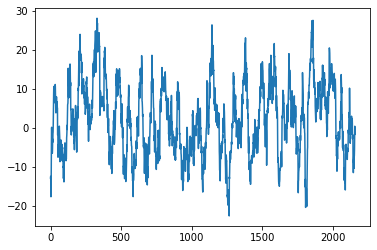


=== Test Period Results ===
PPO Agent Sharpe:     1.234
Total Return:         90.01%
Max Drawdown:         -19.05%


In [6]:
import matplotlib.pyplot as plt

# Initialize
env = CryptoTradingEnv(train_rets)
trainer = PPOTrainer(env, state_size=253, action_size=23)

# Train
network = trainer.train(total_timesteps=500000)

# Evaluate on test data
test_env = CryptoTradingEnv(test_rets)
state, _ = test_env.reset()
portfolio_values = [1.0]
period_returns = []

while True:
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        weights, _ = network(state_tensor)
    
    action = weights.squeeze().numpy()
    next_state, reward, terminated, truncated, _ = test_env.step(action)
    period_returns.append(reward)
    portfolio_values.append(portfolio_values[-1] * (1 + reward))
    state = next_state
    
    if terminated or truncated:
        break

window = 30
rolling_sharpe = []

# Calculate rolling Sharpe ratio
for i in range(window, len(period_returns)):
    returns_window = period_returns[i-window:i]
    mean = np.mean(returns_window)
    std = np.std(returns_window)
    if std > 0:
        sharpe = (mean / std) * np.sqrt(6 * 365)
    else:
        sharpe = 0
    rolling_sharpe.append(sharpe)

# Plot rolling Sharpe ratio
plt.plot(rolling_sharpe, label = 'Rolling Sharpe Ratio (window = 30)')
plt.show()

test_sharpe = np.mean(period_returns) / np.std(period_returns) * np.sqrt(6 * 365)
max_drawdown = min(portfolio_values) / max(portfolio_values[:portfolio_values.index(min(portfolio_values))]) - 1
    
print(f"\n=== Test Period Results ===")
print(f"PPO Agent Sharpe:     {test_sharpe:.3f}")
print(f"Total Return:         {(portfolio_values[-1] - 1) * 100:.2f}%")
print(f"Max Drawdown:         {max_drawdown * 100:.2f}%")